In [7]:
import os
import numpy as np
import scipy
import matplotlib
from matplotlib import pyplot as plt
from numba import jit
import librosa
import pandas as pd
import IPython.display as ipd
from pydub import AudioSegment

filename = os.path.join('dataset','songs', 'Take a Break.mp3')
audio_file = AudioSegment.from_file(filename)

audio_data = np.fromstring(audio_file.raw_data, np.int16)

channels = []
for chn in range(audio_file.channels):
    channels.append(audio_data[chn::audio_file.channels])
    

channel = channels[0]
audio_file.frame_rate

c:\Users\mythk\anaconda3\envs\mir\lib\site-packages\ipykernel_launcher.py:15: DeprecationWarning: The binary mode of fromstring is deprecated, as it behaves surprisingly on unicode inputs. Use frombuffer instead
  from ipykernel import kernelapp as app


44100

In [8]:
from pydub.playback import play
play(audio_file)

PermissionError: [Errno 13] Permission denied: 'C:\\Users\\mythk\\AppData\\Local\\Temp\\tmpfsp7ya45.wav'

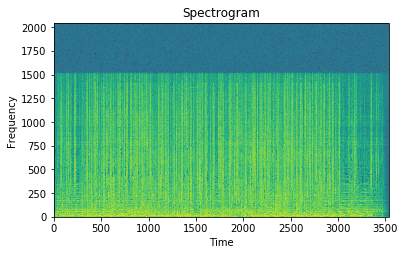

In [9]:
from matplotlib import mlab
from matplotlib import pyplot as plt

window_size = 2**12
window_overlap = int(window_size*0.5)
dfreq = 44100

spectrogram = mlab.specgram(
                channels[0],
                NFFT=window_size,
                Fs=dfreq,
                window=mlab.window_hanning,
                noverlap=window_overlap)[0]

spectrogram = 10*np.log10(spectrogram, out=np.zeros_like(spectrogram), where=(spectrogram != 0))

fig, axes = plt.subplots()
axes.imshow(spectrogram)
axes.set_xlabel('Time')
axes.set_ylabel('Frequency')
axes.set_title('Spectrogram')
plt.gca().invert_yaxis()
plt.show()

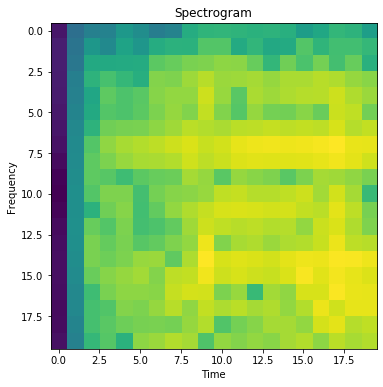

In [12]:
spectrogram_1 = spectrogram[0:20, 0:20]
fig, axes = plt.subplots(figsize=(6,6))
axes.imshow(spectrogram_1)
axes.set_xlabel('Time')
axes.set_ylabel('Frequency')
axes.set_title('Spectrogram')
plt.show()

In [13]:
from scipy.ndimage.morphology import (generate_binary_structure,
                                      iterate_structure,
                                      binary_erosion,)
from scipy.ndimage.filters import maximum_filter

In [14]:
def get_peaks(specgram, no_of_iteration = 10, min_amplitude = 10):
    
    structure = generate_binary_structure(2, 2)
    neighborhood = iterate_structure(structure, no_of_iteration)

    local_max = maximum_filter(specgram, footprint=neighborhood) == specgram

    background = (specgram == 0)
    eroded_background = binary_erosion(background, structure=neighborhood, border_value=1)

    # Applying XOR between matrices to get the boolean mask of specgram
    detected_peaks = local_max ^ eroded_background

    # just getting the peaks, their frequency and time
    peaks = specgram[detected_peaks].flatten()
    peak_freqs, peak_times = np.where(detected_peaks)

    # get indices for frequency and time
    peak_indices = np.where(peaks > min_amplitude)

    freqs = peak_freqs[peak_indices]
    times = peak_times[peak_indices]

    return list(zip(freqs, times))

Total number of peaks in this small portion: 14


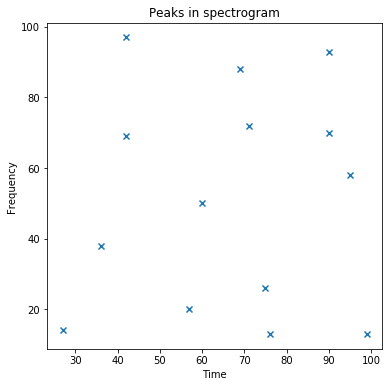

In [15]:
# Plotting small portion of spectrogram

spec_peaks = get_peaks(spectrogram[0:100, 0:100])
print('Total number of peaks in this small portion:', len(spec_peaks))
fig = plt.figure(figsize=(6, 6))
plot_peaks = np.array(spec_peaks)
plt.scatter(plot_peaks[:,1], plot_peaks[:,0], marker='x')
plt.xlabel('Time')
plt.ylabel('Frequency')
plt.title('Peaks in spectrogram')
plt.show()

In [16]:
import pandas as pd
import hashlib
from operator import itemgetter

hash_func = lambda freq1, freq2, offset: hashlib.sha1(
    f"{str(freq1)}|{str(freq2)}|{str(offset)}".encode('utf-8')).hexdigest()[:25]

def get_hashes(peaks, peak_combination = 5):
    peaks.sort(key=itemgetter(1))

    freq_links = []
    for i in range(len(peaks)):
        for j in range(1, peak_combination):
            if (i + j) < len(peaks):

                freq1 = peaks[i][0]
                freq2 = peaks[i + j][0]
                t1 = peaks[i][1]
                t2 = peaks[i + j][1]
                t_delta = t2 - t1 
                freq_links.append((freq1, t1, freq2, t2, t_delta))

    freq_links = pd.DataFrame(freq_links, columns=['freq1', 'time1', 'freq2', 'time2', 'offset'])
    freq_links = freq_links[(freq_links.offset >= 0) & (freq_links.offset < 100)].reset_index(drop=True)
    freq_links['hash'] = freq_links.apply(lambda x: hash_func(x['freq1'], x['freq2'], x['offset']), axis=1)
    return freq_links

hash_df = get_hashes(spec_peaks)
print(hash_df.shape)
hash_df.head()

(46, 6)


,freq1,time1,freq2,time2,offset,hash
0,14,27,38,36,9,33f2b1fc53d7b92248cedf1fd
1,14,27,69,42,15,d1a7eaeca9d4615419bf78955
2,14,27,97,42,15,ddb4510ca9311d341d41f4d9d
3,14,27,20,57,30,a05499d61d06609d13daaba24
4,38,36,69,42,6,7e599ee782ac2e5706292d36a


[[69 42 97 42]
 [69 42 20 57]
 [69 42 50 60]
 [69 42 88 69]]


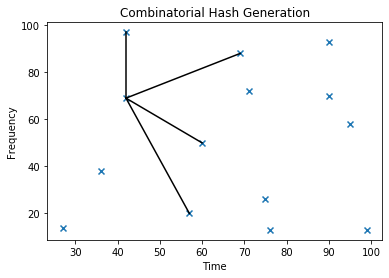

In [17]:
rand_n = hash_df.sample()
const_arr = hash_df[(hash_df['freq1'] == rand_n['freq1'].iloc[0]) & (hash_df['time1'] == rand_n['time1'].iloc[0])]
const_arr = const_arr.values[:, 0:4]
print(const_arr)


plt.scatter(plot_peaks[:,1], plot_peaks[:,0], marker='x')
for y1, x1, y2, x2 in const_arr:
    plt.plot([x1,x2],[y1,y2],'k-')

plt.xlabel('Time')
plt.ylabel('Frequency')
plt.title('Combinatorial Hash Generation')    
plt.show()

In [18]:
def load_file(filename):
    audio_file = AudioSegment.from_file(filename)

    audio_data = np.fromstring(audio_file.raw_data, np.int16)

    channels = []
    for chn in range(audio_file.channels):
        channels.append(audio_data[chn::audio_file.channels])
    return channels

In [19]:
def find_specgram(channel):
    window_size = 2**12
    window_overlap = int(window_size*0.5)
    dfreq = 44100

    spectrogram = mlab.specgram(
                    channel,
                    NFFT=window_size,
                    Fs=dfreq,
                    window=mlab.window_hanning,
                    noverlap=window_overlap)[0]
    
    spectrogram = 10*np.log10(spectrogram, out=np.zeros_like(spectrogram), where=(spectrogram != 0))
    return spectrogram

In [22]:
def load_directory(path):
    
    hash_df = pd.DataFrame(columns=['song_id', 'song_name', 'freq1', 'time1', 'freq2', 'time2', 'offset', 'hash'])
    song_id = 1
    
    for file_name in os.listdir(path):

        if file_name.endswith('.mp3'):
            song_name = file_name[:-4]
            print(f'Started reading file: {song_name} ...')
            channels = load_file(os.path.join(path, file_name))

            for channel in channels:
                spectrogram = find_specgram(channel)
                peaks = get_peaks(spectrogram)
                hashes = get_hashes(peaks)
    
                hashes.loc[:, 'song_id'] = song_id
                hashes.loc[:, 'song_name'] = song_name
                hash_df = hash_df.append(hashes)
            print(f'Completed reading file: {song_name} ...\n')
            
            song_id += 1

    hash_df = hash_df.drop_duplicates(subset=['song_id', 'song_name', 'time1', 'hash'])
    hash_df.reset_index(drop=True, inplace=True)
    hash_df = hash_df[['song_id', 'song_name', 'freq1', 'time1', 'freq2', 'time2', 'offset', 'hash']]
    return hash_df

In [23]:
dir_path = os.path.join('dataset','songs')
hash_df = load_directory(dir_path)

print(hash_df.shape)
hash_df.head()

Started reading file: (When You Gonna) Give It Up to Me - Radio Version ...


c:\Users\mythk\anaconda3\envs\mir\lib\site-packages\ipykernel_launcher.py:4: DeprecationWarning: The binary mode of fromstring is deprecated, as it behaves surprisingly on unicode inputs. Use frombuffer instead
  after removing the cwd from sys.path.


Completed reading file: (When You Gonna) Give It Up to Me - Radio Version ...

Started reading file: 1 0 0  m i l ‘ ...
Completed reading file: 1 0 0  m i l ‘ ...

Started reading file: 1-800-273-8255 ...
Completed reading file: 1-800-273-8255 ...

Started reading file: 100 Summers ...
Completed reading file: 100 Summers ...

Started reading file: 151 Rum (Audio) ...
Completed reading file: 151 Rum (Audio) ...

Started reading file: 247 ...
Completed reading file: 247 ...

Started reading file: 25 To Life ...
Completed reading file: 25 To Life ...

Started reading file: 27 - Machine Gun Kelly (MGK) ...
Completed reading file: 27 - Machine Gun Kelly (MGK) ...

Started reading file: 305 To My City ...
Completed reading file: 305 To My City ...

Started reading file: 44 Bars ...
Completed reading file: 44 Bars ...

Started reading file: 50 Cent - Many men (wish death) ...
Completed reading file: 50 Cent - Many men (wish death) ...

Started reading file: 50 in da Safe ...
Completed reading